In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
import os

os.chdir("..")  # run once

from dirdet.config.physics import  NeutrinoRegistry, SignalType
from dirdet.config.targets import FLUORINE

from dirdet.helpers import neutrino_angles
from dirdet.nuclear_phyics import form_factor_helm
from dirdet.neutrino_rates import dRdEdO_CEvNS
from dirdet.plotting import plot_neutrino_flavour

# flux and energy data location
flux_path: str = "input_data/neutrino_fluxes"

# Theory

## Kinematic Constriant

We will now move on to representing the **directional** recoil rate, whereby the recoil rate is now a fucntion of both recoil energy $E_r$ **and** the angle of recoil $\theta$. $\theta$ stems from the kinematical relationship between the recoil energy and angle of the two colliding particles,
$$\cos{\theta}=\frac{v_{min}}{v}\text{.}$$

We explicitly define the kinamatical constraint in terms of $\cos{\beta}$ such that:
$$
\cos\beta= \hat{\mathbf{q}} \cdot \hat{\mathbf{q}}_{\nu}=\frac{E_{\nu} + m_{N}}{E_{\nu}}\sqrt{ \frac{E_{r}}{2m_{N}} }
$$
where $\hat{\mathbf{q}}_{\nu}$ is the direction of the incoming neutrino.

Using this equation, we can also define the maximum recoil energy that the neutrinos can generate, by setting $\beta=0$ to obtain 
$$
E_{r}^{\text{max}} \approx \frac{2E^{2}_{\nu}}{m_{N}+2E_{\nu}} \text{.}
$$
This is encoded into the functions, to ensure rates are consistent with energy-momentum conservation, analogous to the $v_{\text{min}}$ function for WIMP calcualtions.

## Directional Cross Section 

Defining the solid angle element $d\Omega_{\nu}=2\pi d\cos\beta$, (noting the azimuthal symmetry about the incoming direction) the differential cross section is:
$$
\frac{d^{2}\sigma}{dE_{r}d\Omega_{r}}=\frac{d\sigma}{dE_{r}}\times \frac{1}{2\pi}\delta\left( \cos\beta- \frac{E_{\nu} + m_{N}}{E_{\nu}}\sqrt{ \frac{E_{r}}{2m_{N}} } \right)
$$
with $\frac{d\sigma}{dE_{r}}(E_{r}E_{\nu})$ being the cross section described in `1_neutrino_recoil`.

Finally by implmenting the drectional reocil cross section onto the recoil rate defined in `1_neutrino_recoil_rate`, we obtain the **CEvNS Differential Recoi Rate**:
$$
\frac{dR}{dE_{r}}=\frac{1}{m_{N}} \int_{E_{\nu}^{\text{min}}} \frac{d^{2}\sigma}{dE_{r}d\Omega_{r}} \times \frac{d^{2}\Phi}{dE_{\nu}\Omega_{\nu}} dE_{\nu}d\Omega_{\nu} \text{.}
$$

## Isotropic Neutrinos

The isotropic nature of atmospheric and DSNB neutrinos allows us to simplify the flux modulation and cross section calcualtion, as:
$$
\begin{align*}
\frac{d^{2}\Phi}{dE_{\nu}d\Omega_{\nu}} & = \frac{1}{2\pi} \frac{d\Phi}{dE_{\nu}} \\
\frac{d^{2}\sigma}{dE_{r}d\Omega_{r}} & = \frac{1}{2\pi} \frac{d\sigma}{dE_{r}}\text{.}
\end{align*}
$$
Applying this to the recoil rate defioned above, we simply have
$$
\frac{d^{2}R}{dE_{r}d\Omega_{r}}  = \frac{1}{4\pi m_{N}} \int _{E_{\nu}^{\text{min}}} \frac{d\sigma}{dE_{r}} \times \frac{d\Phi}{dE_{\nu}} dE_{\nu} \text{.}
$$
This is fundamentally just the *non-directional recoil rate*, but with a factor $1/4\pi$ applied, stemming from the treatment of the cross sectiona and flux modulation. 

## Solar Neutrinos

The expression for the flux modulation of solar neturnos is obtained by multiplying the flux with the delta fucntion encoding the kinematic constraint:
$$
\begin{align}
\frac{d^{2}\Phi}{dE_{\nu}d\Omega_{\nu}} &= \frac{d\Phi}{dE_{\nu}} \times \delta(\hat{\mathbf{q}}_{\nu}-\hat{\mathbf{q}}_{\odot}) \\
& = \frac{d\Phi}{dE_{\nu}} \times\delta\left( \hat{\mathbf{q}} \cdot \hat{\mathbf{q}}_{\odot} - \frac{E_{\nu}+m_{N}}{E_{\nu}}\sqrt{ \frac{E_{r}}{2m_{N}} } \right) \\
 & = \frac{d\Phi}{dE_{\nu}} \times \frac{1}{E_{\nu}^{\text{min}}} \times \delta\left( \frac{1}{\varepsilon} -\frac{1}{E_{\nu}^{\text{min}}}\right)\text{,}
\end{align}
$$
where, 
$
1/\varepsilon = (\hat{\mathbf{q}} \cdot \hat{\mathbf{q}}_{\odot}/E_{\nu}^{\text{min}}) - 1/m_{N}$.

Finally, substituting this flux modulation into the recoil rate, and integrating over the neutirno direction $\Omega_{\nu}$, the analytical expression for the differential recoil is:
$$
\left. \frac{d^2R}{dE_rd\Omega_r} = \frac{1}{2\pi m_N}\frac{\varepsilon^2}{E_\nu^{min}}\left(\frac{d\sigma}{dE_r}\frac{d\Phi}{d\varepsilon}\right) \right|_{E_\nu=\varepsilon} \text{.}
$$
It is worth noting that the calculation of the recol rate has pivoted from $E_\nu$ to $\varepsilon$, which necessities the inclusion of an interpolation method to obtain the flux. However for monochromatic neutrinos this is not used, and instead the angular dependence is taken into account by comparing the recoil $\cos{\beta}$ with the angle between the solar and recoil
vector $\cos\theta_{\odot} = \hat{\mathbf{q}} \cdot \hat{\mathbf{q}}_{\odot} $. If the difference between the two values is greater than some custom parameter $\eta$, the rate is set to 0.

# Calculation

In [2]:
tagrget = FLUORINE
E_r = np.geomspace(1e-3,1e3,1000)   # recoil energy
cosThetaSun_arr = neutrino_angles(xpix_num=16,mask=False)    # angle of origin


# define which neutrinos to use
#neutrinos = NeutrinoRegistry.by_name(["8B","13N","7Be1","Atm"])
neutrinos = NeutrinoRegistry.all_sources()

# define dictionay of values
dR_mat_dic = {key.name: [] for key in neutrinos}

# calcualte 
FF = form_factor_helm(E_r=E_r, A=tagrget.A)


for nu in neutrinos:
    E_nu, Flux = nu.get_nu_energy_and_flux(path=flux_path)
    
    # calcualte recoil rate
    dR_mat = dRdEdO_CEvNS(
        neutrino=nu, E_nu=E_nu, Flux=Flux,
        E_r=E_r, cosThetaSun_arr=cosThetaSun_arr,
        FF=FF
    )

    dR_mat_dic[nu.name] = dR_mat    

## Plotting 

We will now plot the recoil rate as a function of energy for different angles on the left. On the right, we will plot the rate, integreated across the recoil energy as a function of angle. We will do this with four neutrinos, to prevent overcrowding.

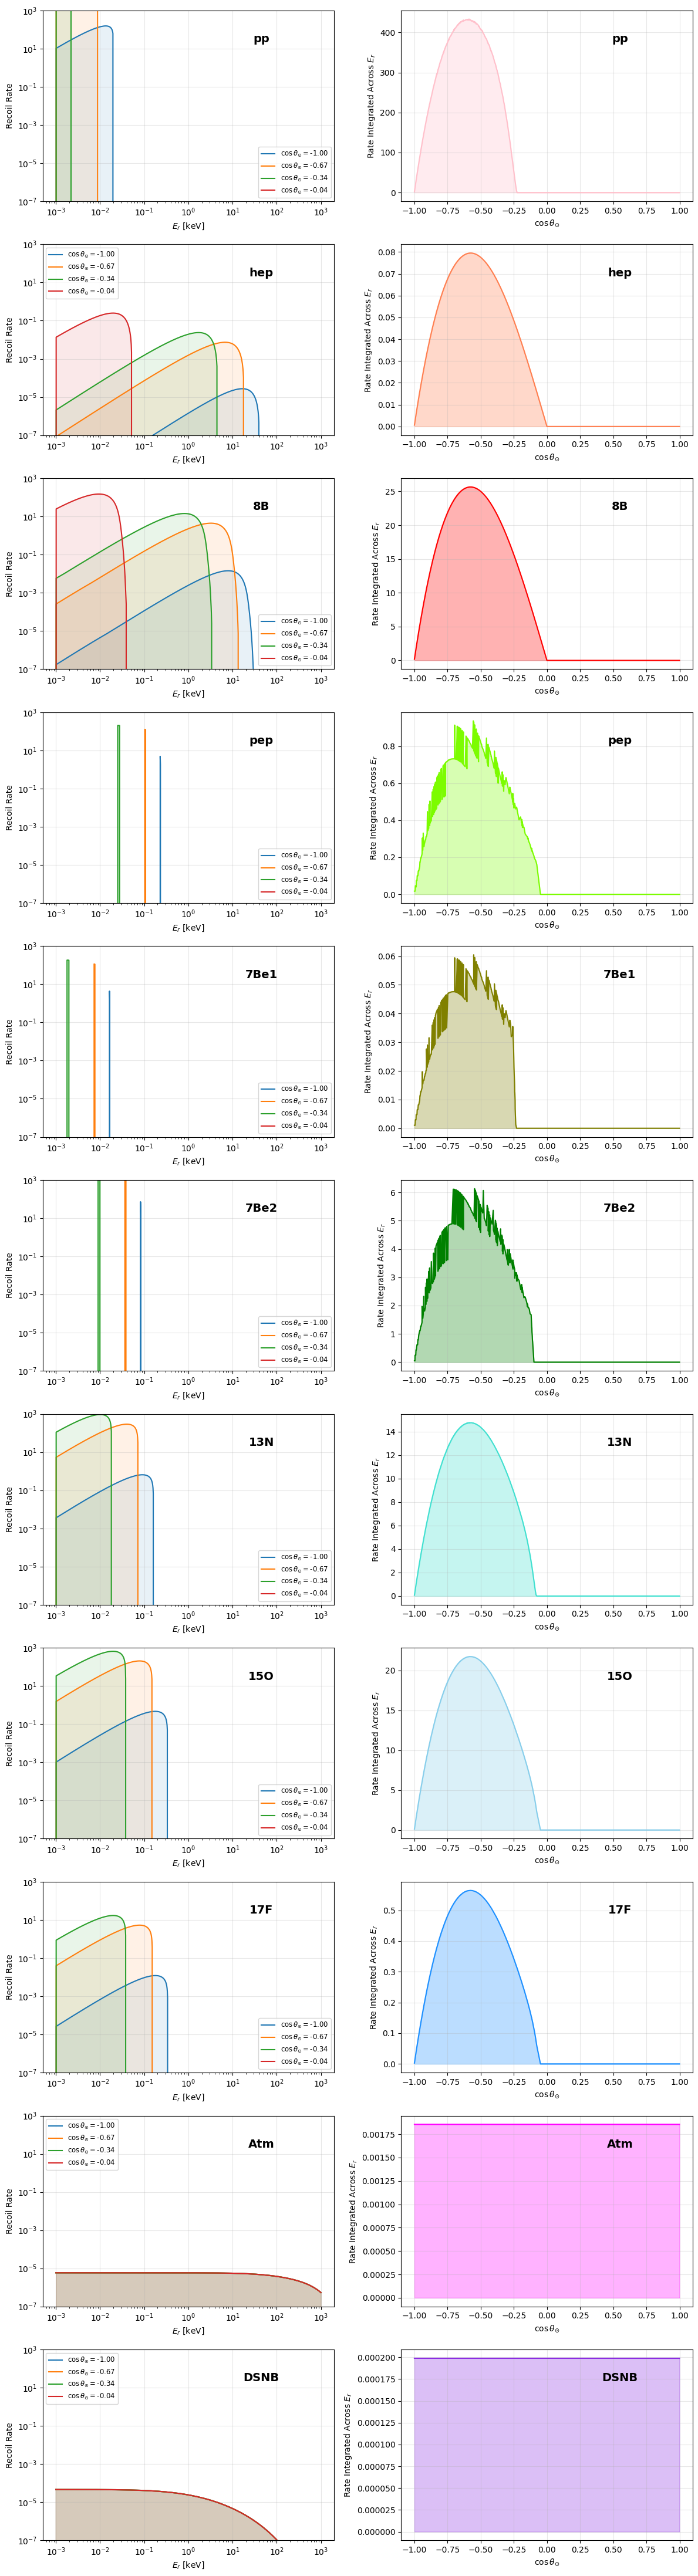

In [3]:

plot_nu = NeutrinoRegistry.all_sources()
num_nus = len(plot_nu)
num_param = 4
# define angles
negCosArr = np.sort(cosThetaSun_arr[cosThetaSun_arr < 0.0])
values = negCosArr[np.linspace(0, len(negCosArr) - 1, num_param, dtype=int)]
cos_angle_indices = [np.argwhere(cosThetaSun_arr==v).flatten()[1] for v in values]

# figure
fig, axes = plt.subplots(num_nus, 2, figsize=(12, 4*(num_nus)))
ax_left, ax_right = axes[:,0].flatten(), axes[:,1].flatten()

# calc and plot
for i, nu in enumerate(plot_nu):
    ax_l, ax_r = ax_left[i], ax_right[i]
    ax_l.text(0.75, 0.85, nu.name, transform=ax_l.transAxes, 
            ha='center', va='center', fontsize=14, fontweight='bold')    
    ax_r.text(0.75, 0.85, nu.name, transform=ax_r.transAxes, 
            ha='center', va='center', fontsize=14, fontweight='bold')    
    ax_l.grid(alpha=0.3), ax_r.grid(alpha=0.3)
    ax_l.set_xlabel("$E_r$ [keV]"), ax_r.set_xlabel("$\\cos{\\theta_{\\odot}}$")
    ax_l.set_ylabel("Recoil Rate"), ax_r.set_ylabel("Rate Integrated Across $E_r$")
    ax_l.set_ylim(1e-7,1e3)
    
    #ax_l.set_ylim(1e-7)
    dR_mat = dR_mat_dic[nu.name]
    
    # plot dR vs E_r
    for angle_index in cos_angle_indices:
        x = E_r
        y = dR_mat[angle_index] 
        #y = dR_mat[angle_index]
        label = f"$\\cos\\theta_{{\\odot}}=${cosThetaSun_arr[angle_index]:.2f}"
        plot_neutrino_flavour(ax=ax_l, source=nu, x_arr=x, y_arr=y, how="loglog", 
                              fill=True, use_source_col=False, 
                              manual_label=label,fill_alpha=0.1)
    
    # plot int(dR,E_R) vs angle
    x = cosThetaSun_arr
    y = np.trapezoid(dR_mat, x=E_r, axis=1)
    
    plot_neutrino_flavour(ax=ax_r, source=nu, x_arr=x, y_arr=y, how="plot", 
                            fill=True, use_source_col=True, fill_alpha=0.3)

    ax_l.legend(loc="best",fontsize="small")

fig.tight_layout()

# Surface and Colour Plot

We will now plot the recoil rate as a function of energy and angle. On the left hand side this will be a surface plot, and the right will be the colour plot

In [4]:
negCosThetaSun_arr = cosThetaSun_arr[cosThetaSun_arr <= 0]
neutrinos = NeutrinoRegistry.all_sources()
dR_mat_dic = {nu.name: [] for nu in neutrinos}

for nu in neutrinos:
    E_nu, Flux = nu.get_nu_energy_and_flux(path=flux_path)  # load flux and nu energy
    E_r = np.geomspace(1e-3, nu.max_fl_recoil ,1000)      # define energy range
    FF = form_factor_helm(E_r=E_r, A=tagrget.A)         # form factor

    # calculate
    dR_mat = dRdEdO_CEvNS(
        neutrino=nu, E_nu=E_nu, Flux=Flux,
        E_r=E_r, cosThetaSun_arr=negCosThetaSun_arr, FF=FF
    )
 
    # allocate in dic
    dR_mat_dic[nu.name] = dR_mat

## Plotting

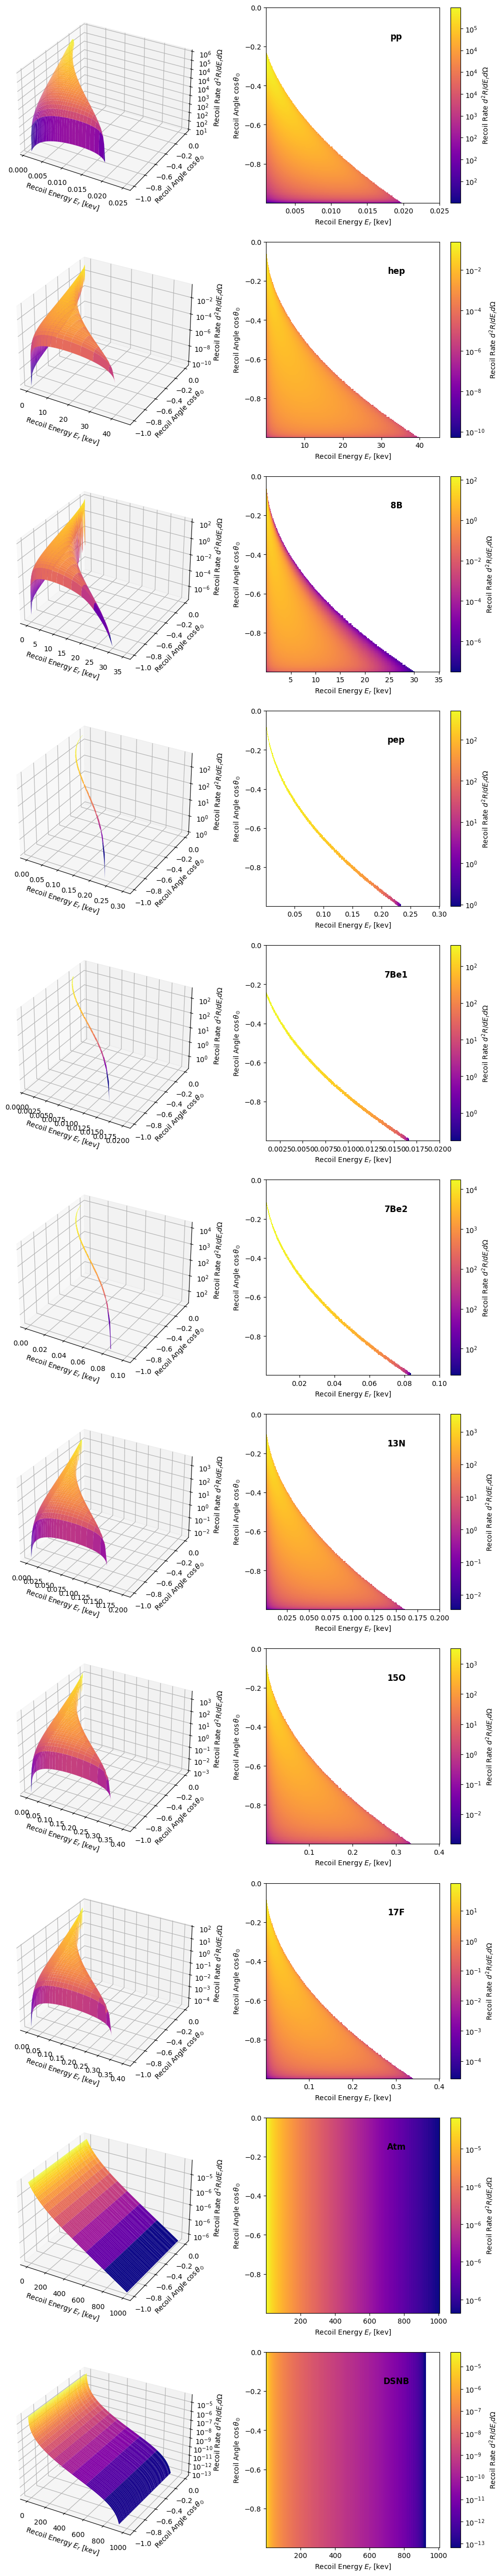

In [5]:
# loop over neutrinos
neutrinos = NeutrinoRegistry.all_sources()
n = len(neutrinos)

fig = plt.figure(figsize=(14,6*n))
gs = gridspec.GridSpec(n, 2, width_ratios=[1.5, 1], wspace=0.0)

sort_idx = np.argsort(negCosThetaSun_arr)   # sorted indices
negCosThetaSun_arr_sort = negCosThetaSun_arr[sort_idx]

def log_tick_formatter(val, pos):
    return f"$10^{{{val:.0f}}}$"

xlabel = "Recoil Energy $E_r$ [kev]"
ylabel = "Recoil Angle $\\cos{\\theta_{\\odot}}$"
zlabel = "Recoil Rate $d^2R/dE_rd\\Omega$"

for i, nu in enumerate(neutrinos):
    # define axis
    ax_left = fig.add_subplot(gs[i, 0], projection='3d')
    ax_right = fig.add_subplot(gs[i, 1])
    ax_right.text(0.75, 0.85, nu.name, transform=ax_right.transAxes, 
        ha='center', va='center', fontsize=12, fontweight="bold")
    E_r_nu = np.geomspace(1e-3,nu.max_fl_recoil,1000)
    dR_mat = dR_mat_dic[nu.name]
    dR_safe = np.where(dR_mat > 0, dR_mat, np.nan)[sort_idx,:]
    energy, angles = np.meshgrid(E_r_nu, negCosThetaSun_arr_sort)

    # colour plot
    mesh = ax_right.pcolormesh(energy, angles, np.log10(dR_safe),cmap="plasma")
    cbar = fig.colorbar(mesh, ax=ax_right)
     
    # formatting
    ax_right.set_xlabel(xlabel), ax_right.set_ylabel(ylabel)
    cbar.set_label(zlabel)
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))


    # surf plot
    surf = ax_left.plot_surface(energy, angles, np.log10(dR_safe),cmap="plasma")
    
    # formatting
    ax_left.set_xlabel(xlabel), ax_left.set_ylabel(ylabel), ax_left.set_zlabel(zlabel)
    ax_left.zaxis.set_major_formatter(FuncFormatter(log_tick_formatter))

    
